# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
G = 6.67e-11
g = 9.81
M_E = 5.9e24
M_M = 7.3e22
R_E = 6378e3
R_M = 1737e3
d_EM = 3.8e8
m_apollo = 5500
x_moon = d_EM / np.sqrt(2)
y_moon = d_EM / np.sqrt(2)


## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def gravitational_potential(M, x_M, y_M, x, y):
    """
    Return the gravitational potential Phi = -GM/r.
    Only works for single values or numpy arrays.
    """
    #was told this is best for errors 
    r = np.sqrt((x - x_M)**2 + (y - y_M)**2)

    if np.isscalar(r):
        if r == 0:
            return np.nan
        return -G * M / r

    r = np.where(r == 0, np.nan, r)
    return -G * M / r

#Thought I should have function return something 

phi_test = gravitational_potential(M_E, 0, 0, R_E, 0)
print(phi_test)


-61701160.238319226


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

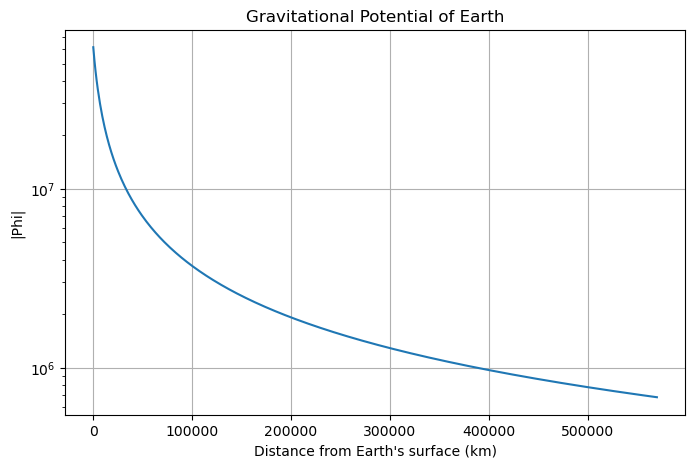

In [4]:
x_surface = np.linspace(0, 1.5 * d_EM, 500)
phi_1d = np.abs(gravitational_potential(M_E, 0, 0, R_E + x_surface, 0))

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(x_surface / 1000, phi_1d)
ax.set_yscale("log")
ax.set_xlabel("Distance from Earth's surface (km)")
ax.set_ylabel("|Phi|")
ax.set_title("Gravitational Potential of Earth")
ax.grid(True)

plt.show()


3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

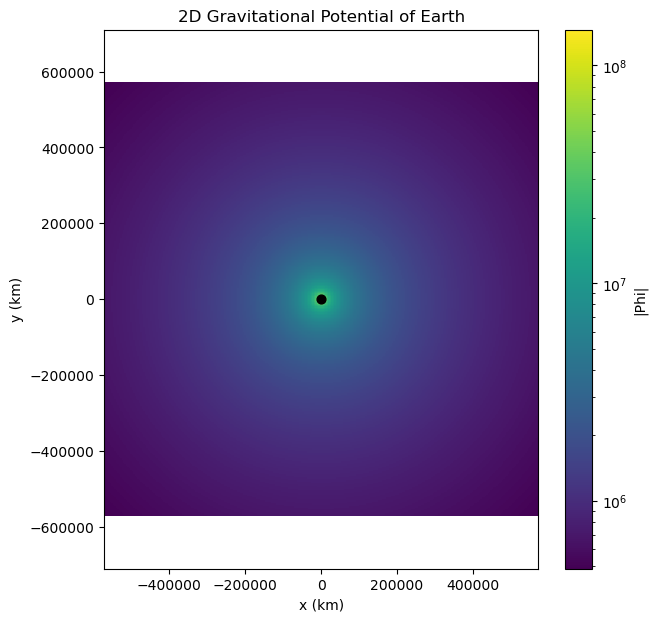

In [5]:
x_vals = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 300)
y_vals = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 300)
X, Y = np.meshgrid(x_vals, y_vals)

phi_earth = np.abs(gravitational_potential(M_E, 0, 0, X, Y))

plt.figure(figsize=(7, 7))
mesh = plt.pcolormesh(X / 1000, Y / 1000, phi_earth, shading="auto", norm=LogNorm())     #had to search up pcolormesh
plt.colorbar(mesh, label="|Phi|")
plt.scatter(0, 0, color="black", s=40)
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("2D Gravitational Potential of Earth")
plt.axis("equal")
plt.show()


## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

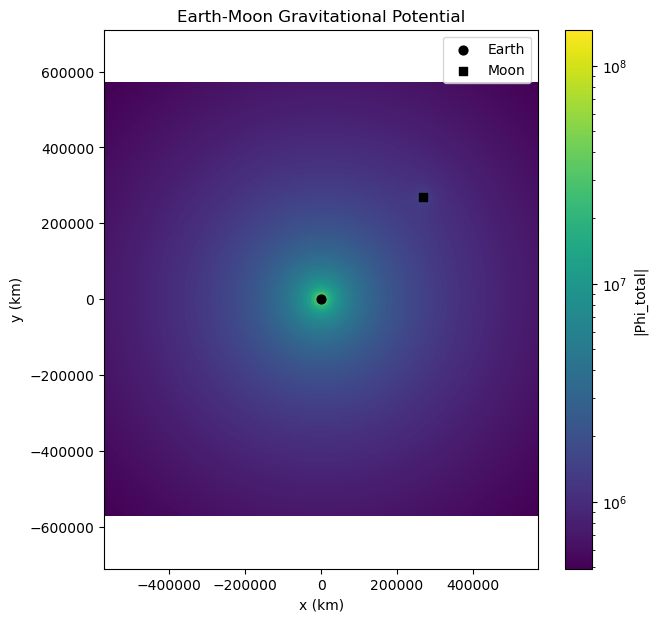

In [6]:
phi_total = np.abs(gravitational_potential(M_E, 0, 0, X, Y)+ gravitational_potential(M_M, x_moon, y_moon, X, Y))

plt.figure(figsize=(7, 7))
mesh = plt.pcolormesh(X / 1000, Y / 1000, phi_total, shading="auto", norm=LogNorm())
plt.colorbar(mesh, label="|Phi_total|")
plt.scatter(0, 0, color="black", s=40, label="Earth")
plt.scatter(x_moon / 1000, y_moon / 1000, color="black", marker="s", s=40, label="Moon")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Earth-Moon Gravitational Potential")
plt.axis("equal")
plt.legend()
plt.show()


2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

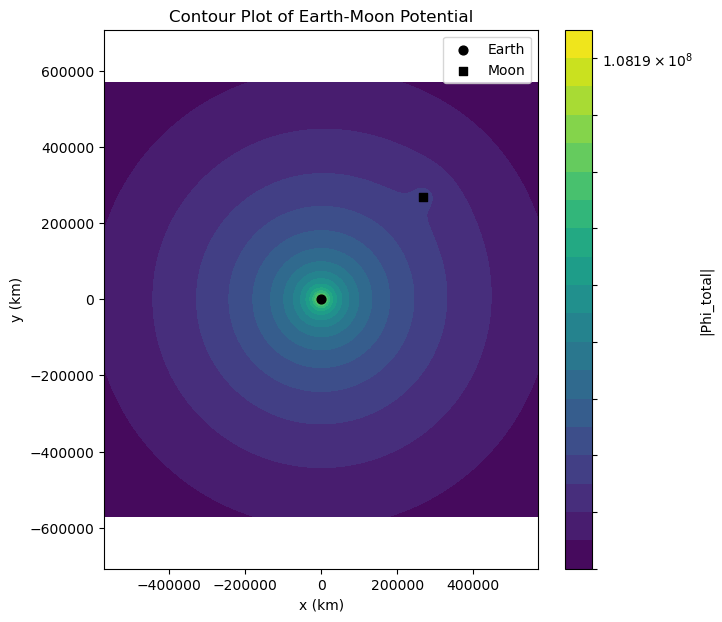

In [7]:
levels = np.logspace(np.log10(np.nanmin(phi_total)), np.log10(np.nanmax(phi_total)), 20) #had to lookup and consult online 

plt.figure(figsize=(7, 7))
contours = plt.contourf(X / 1000, Y / 1000, phi_total, levels=levels, norm=LogNorm())
plt.colorbar(contours, label="|Phi_total|")
plt.scatter(0, 0, color="black", s=40, label="Earth")
plt.scatter(x_moon / 1000, y_moon / 1000, color="black", marker="s", s=40, label="Moon")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Contour Plot of Earth-Moon Potential")
plt.axis("equal")
plt.legend()
plt.show()


## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def gravitational_force(M1, m2, x1, y1, x2, y2):
    """
    Return the x and y components of gravitational force on m2 from M1.
    Works for single values or numpy arrays.
    """
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)

    if np.isscalar(r):
        if r == 0:
            return np.nan, np.nan
        Fx = -G * M1 * m2 * dx / r**3
        Fy = -G * M1 * m2 * dy / r**3
        return Fx, Fy

    r = np.where(r == 0, np.nan, r)
    Fx = -G * M1 * m2 * dx / r**3
    Fy = -G * M1 * m2 * dy / r**3
    return Fx, Fy

Fx_test, Fy_test = gravitational_force(M_E, M_M, 0, 0, d_EM, 0)

print("Fx =", Fx_test)
print("Fy =", Fy_test)


Fx = -1.9894522160664822e+20
Fy = -0.0


2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

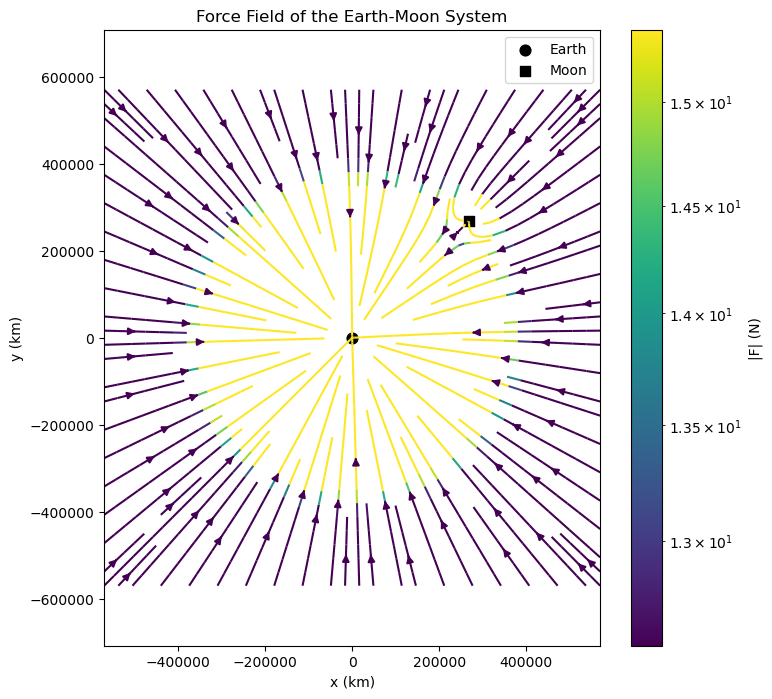

In [9]:
x_force = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 120)
y_force = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 120)
XF, YF = np.meshgrid(x_force, y_force)

Fx_earth, Fy_earth = gravitational_force(M_E, m_apollo, 0, 0, XF, YF)
Fx_moon, Fy_moon = gravitational_force(M_M, m_apollo, x_moon, y_moon, XF, YF)

Fx_total = Fx_earth + Fx_moon
Fy_total = Fy_earth + Fy_moon
F_mag = np.sqrt(Fx_total**2 + Fy_total**2)

plt.figure(figsize=(8, 8))
stream = plt.streamplot(
    XF / 1000,
    YF / 1000,
    Fx_total,
    Fy_total,
    color=F_mag,
    cmap="viridis",
    norm=LogNorm(),
    density=1.2
)
plt.colorbar(stream.lines, label="|F| (N)")
plt.scatter(0, 0, color="black", s=60, label="Earth")
plt.scatter(x_moon / 1000, y_moon / 1000, color="black", marker="s", s=60, label="Moon")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Force Field of the Earth-Moon System")
plt.axis("equal")
plt.legend()
plt.show()


3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

We want to find the point where the gravitational force from the Earth
is equal to the gravitational force from the Moon.

The gravitational force formula is:

F = G M m / r^2

At the balance point:

F_earth = F_moon

So:

G * M_earth * m / r_earth^2 = G * M_moon * m / r_moon^2

Cancel G and m from both sides:

M_earth / r_earth^2 = M_moon / r_moon^2

Take the square root of both sides:

sqrt(M_earth) / r_earth = sqrt(M_moon) / r_moon

Solve for the distances:

r_earth / r_moon = sqrt(M_earth / M_moon)

Let the total Earth–Moon distance be d_EM.

Then:

r_earth + r_moon = d_EM

Using the mass ratio we can solve for r_earth:

r_earth = d_EM / (1 + sqrt(M_moon / M_earth))

Once r_earth is known, the coordinates of the balance point lie
along the Earth-Moon line. Since the Moon is located at

(x_M, y_M) = (d_EM / sqrt(2), d_EM / sqrt(2))

the balance point coordinates are:

x_balance = (r_earth / d_EM) * x_M
y_balance = (r_earth / d_EM) * y_M


And your updated plot, including the balance point, goes in the cell below.

Balance point distance from Earth = 341962346.91181517 m
Balance point x = 241803894.4118111 m
Balance point y = 241803894.4118111 m


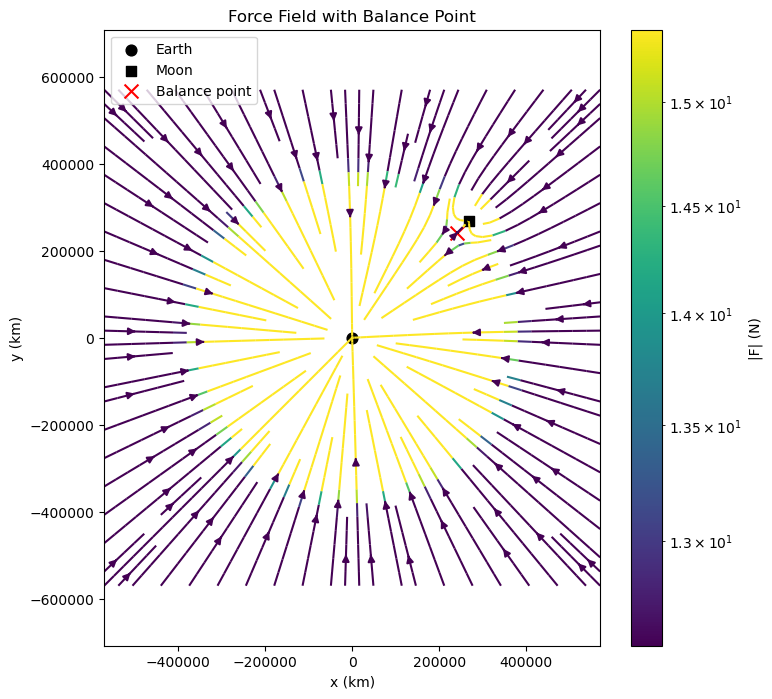

In [10]:
r_balance = d_EM / (1 + np.sqrt(M_M / M_E))
x_balance = r_balance / np.sqrt(2)
y_balance = r_balance / np.sqrt(2)

print("Balance point distance from Earth =", r_balance, "m")
print("Balance point x =", x_balance, "m")
print("Balance point y =", y_balance, "m")

plt.figure(figsize=(8, 8))
stream = plt.streamplot(
    XF / 1000,
    YF / 1000,
    Fx_total,
    Fy_total,
    color=F_mag,
    cmap="viridis",
    norm=LogNorm(),
    density=1.2
)
plt.colorbar(stream.lines, label="|F| (N)")
plt.scatter(0, 0, color="black", s=60, label="Earth")
plt.scatter(x_moon / 1000, y_moon / 1000, color="black", marker="s", s=60, label="Moon")
plt.scatter(x_balance / 1000, y_balance / 1000, color="red", marker="x", s=100, label="Balance point")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Force Field with Balance Point")
plt.axis("equal")
plt.legend()
plt.show()


4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is much closer to the Moon than to the Earth. From the calculation, the balance point is about 341,962 km from Earth along the Earth-Moon line.

This means it is about 42,000 km away from the Moon since the total Earth-Moon distance is about 384,000 km.

This makes sense because the Earth is much more massive than the Moon (about 81 times more massive). Since Earth’s gravity is stronger, the point where the gravitational forces cancel must be closer to the Moon so that the Moon’s weaker gravity can balance Earth’s stronger pull.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

In [11]:
from scipy.integrate import quad 

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [12]:
m0 = 2.30e6     
mf = 1.30e5      
mdot = (m0 - mf) / 160   
ve = 2580        
g = 9.81        

T = (m0 - mf) / mdot
print("Burn time T =", T, "seconds")

Burn time T = 160.0 seconds


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [13]:
def delta_v(t, m0, mf, mdot, ve, g):
    """
    Return the rocket velocity change at time t.
    If the fuel is gone, return 0.
    """
    T = (m0 - mf) / mdot

    if t < 0:
        return 0
    if t > T:
        return 0

    m_t = m0 - mdot * t
    return ve * np.log(m0 / m_t) - g * t

#Not sure if you want us to call the function but thought I'd do it anyways

test_velocity = delta_v(10, m0, mf, mdot, ve, g)

print("Delta v at t = 10 seconds:", test_velocity)

Delta v at t = 10 seconds: 58.70591584223122


3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [14]:
from scipy.integrate import quad #another way to use the scipy.integrate.quad function so I'm told from office hours 
import numpy as np

h, err = quad(delta_v, 0, T, args=(m0, mf, mdot, ve, g))

print("Altitude at burnout h =", h, "meters")
#want to use proper SI units

Altitude at burnout h = 216179.62870265509 meters


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

My calculated burn time is about 160 s, which matches the NASA test result pretty well.

My calculated altitude is about 216 km, which is much larger than the reported 70 km. This means the model is an overestimate.

A main reason is that this calculation uses a very simplified rocket equation and ignores important real-world effects like drag and non constant engine performance. Those effects would lower the real altitude, so it makes sense that the true test altitude is much smaller than the ideal version.